# geoexposure — Milan NO₂ population exposure demo

This notebook walks through the full `geoexposure` processing chain on real
Milan data:

**stations (NO₂) → grid → IDW interpolation → population weighting → exposure & equity**

Key idea: the *spatial* mean of a pollution map treats empty land and dense
city alike. **Population-weighted exposure (PWE)** weights each cell by how many
people live there, answering *"what does the average person actually breathe?"*.
`exposure_bias` quantifies the gap.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import geoexposure as gx
print("geoexposure version:", gx.__version__)

geoexposure version: 0.1.0


## 1. Load real Milan data (EPSG:32632)

ISTAT boundary, ARPA Lombardia NO₂ stations, ISTAT 2021 census population (500 m grid).

stations:        16  (NO2 16.6-41.5 ug/m3)
population cells: 6687   total population: 3,214,630


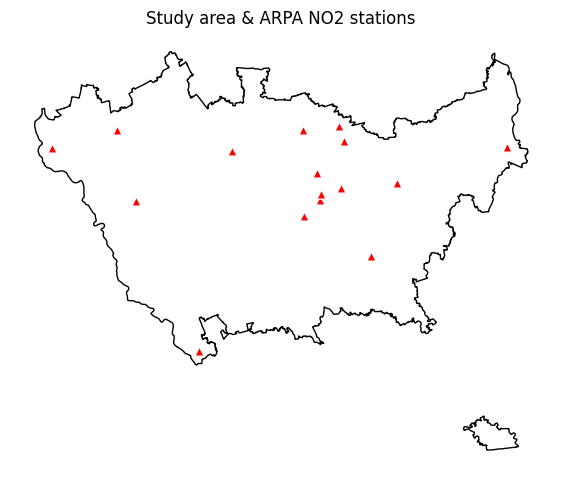

In [2]:
data = gx.load_sample_data()
boundary, stations, pop = data["boundary"], data["stations"], data["population_grid"]
print(f"stations:        {len(stations)}  (NO2 {stations['no2'].min():.1f}-{stations['no2'].max():.1f} ug/m3)")
print(f"population cells: {len(pop)}   total population: {int(pop['population'].sum()):,}")

ax = boundary.plot(facecolor="none", edgecolor="black", figsize=(7, 7))
stations.plot(ax=ax, color="red", marker="^", markersize=45, edgecolor="white")
ax.set_title("Study area & ARPA NO2 stations"); ax.set_axis_off(); ax.set_aspect("equal")

## 2. Build the analysis grid

A square grid at 500 m aligns 1:1 with the census grid.

In [3]:
grid = gx.create_regular_grid(boundary, cell_size=500)
print("square grid cells:", len(grid))

square grid cells: 6689


## 3. IDW interpolation

Each cell centroid gets an inverse-distance-weighted average of the station
values. Note the 'bull's-eye' artefacts at station locations — a known IDW
characteristic. IDW is a convex combination, so values never exceed the
station min/max (it cannot extrapolate a hotspot that no station saw).

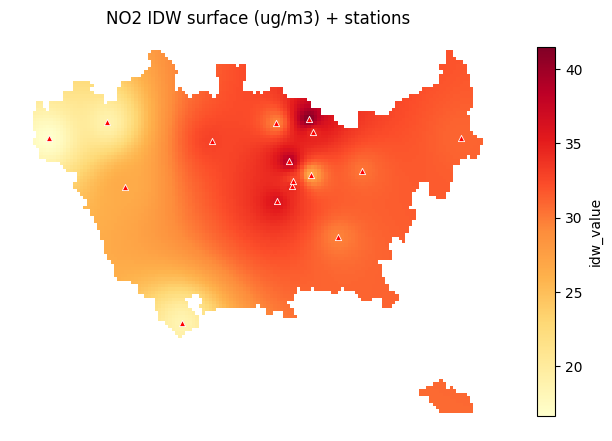

In [4]:
grid = gx.idw_interpolation(stations, grid, value_col="no2", power=2)
ax = gx.plot_choropleth(grid, "idw_value", cmap="YlOrRd", points_gdf=stations,
                        title="NO2 IDW surface (ug/m3) + stations")

## 4. Attach population & compute exposure

We sum each census cell's population into the analysis cell that contains its
centroid (full population coverage, works for any grid shape).

In [5]:
def attach_population(grid, pop, col="population"):
    census = pop.copy(); census["geometry"] = pop.geometry.centroid
    j = gpd.sjoin(census[[col, "geometry"]], grid[["grid_id", "geometry"]],
                  predicate="within", how="left")
    grid = grid.copy()
    grid["population"] = grid["grid_id"].map(j.groupby("grid_id")[col].sum()).fillna(0.0)
    return grid

grid = attach_population(grid, pop)
pwe  = gx.population_weighted_exposure(grid, "idw_value", "population")
awm  = gx.area_weighted_mean(grid, "idw_value")
bias = gx.exposure_bias(pwe, awm)

pd.DataFrame({"metric": ["population_weighted_exposure", "area_weighted_mean", "exposure_bias_%"],
              "value":  [round(pwe, 2), round(awm, 2), round(bias, 2)]})

,metric,value
0,population_weighted_exposure,32.01
1,area_weighted_mean,29.49
2,exposure_bias_%,8.53


**Reading the result:** PWE > area mean, so the bias is **positive** —
ignoring where people live *underestimates* real human exposure, because
population concentrates in the higher-NO₂ urban core.

## 5. Equity / environmental-justice summary

Compare population-weighted exposure of the top 25% vs bottom 25% cells.

In [6]:
eq = gx.exposure_inequality_summary(grid, "idw_value", "population", quantile=0.25)
pd.Series(eq).round(3)

high_exposure_mean    34.012
low_exposure_mean     23.934
ratio                  1.421
pop_share_high         0.602
dtype: float64

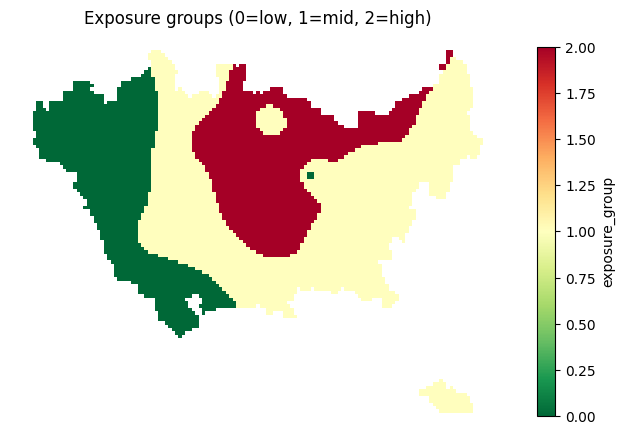

In [7]:
hi, lo = grid["idw_value"].quantile(0.75), grid["idw_value"].quantile(0.25)
grid["exposure_group"] = 1
grid.loc[grid["idw_value"] >= hi, "exposure_group"] = 2
grid.loc[grid["idw_value"] <= lo, "exposure_group"] = 0
ax = gx.plot_choropleth(grid, "exposure_group", cmap="RdYlGn_r",
                        title="Exposure groups (0=low, 1=mid, 2=high)")

## 6. MAUP — robustness to the analysis unit

Grid-based metrics depend on the **Modifiable Areal Unit Problem (MAUP)**:
the *scale* effect (cell size) and the *zonation* effect (cell shape). We vary
both and check that the conclusion is stable — if it is, it is not an artefact
of the discretisation.

In [8]:
def run(grid):
    grid = gx.idw_interpolation(stations, grid, "no2", power=2)
    grid = attach_population(grid, pop)
    pwe = gx.population_weighted_exposure(grid, "idw_value", "population")
    awm = gx.area_weighted_mean(grid, "idw_value")
    eq  = gx.exposure_inequality_summary(grid, "idw_value", "population")
    return grid, {"cells": len(grid), "PWE": round(pwe, 2),
                  "bias_%": round(gx.exposure_bias(pwe, awm), 2),
                  "inequality_ratio": round(eq["ratio"], 2),
                  "pop_share_high": round(eq["pop_share_high"], 3)}

### 6a. Scale effect — vary the resolution (square grid)

In [9]:
scale = []
for cs in (250, 500, 1000):
    _, m = run(gx.create_regular_grid(boundary, cs))
    scale.append({"cell_size_m": cs, **m})
pd.DataFrame(scale)

,cell_size_m,cells,PWE,bias_%,inequality_ratio,pop_share_high
0,250,26057,31.99,8.35,1.42,0.599
1,500,6689,32.01,8.53,1.42,0.602
2,1000,1759,32.01,8.70,1.43,0.608


### 6b. Zonation effect — square vs hexagonal grid

In [10]:
sq_grid, sq = run(gx.create_regular_grid(boundary, 500))
hx_grid, hx = run(gx.create_hexagonal_grid(boundary, 300))
pd.DataFrame({"square_500m": sq, "hexagon_R300m": hx})

,square_500m,hexagon_R300m
cells,6689.000,7143.000
PWE,32.010,32.000
bias_%,8.530,8.490
inequality_ratio,1.420,1.430
pop_share_high,0.602,0.603


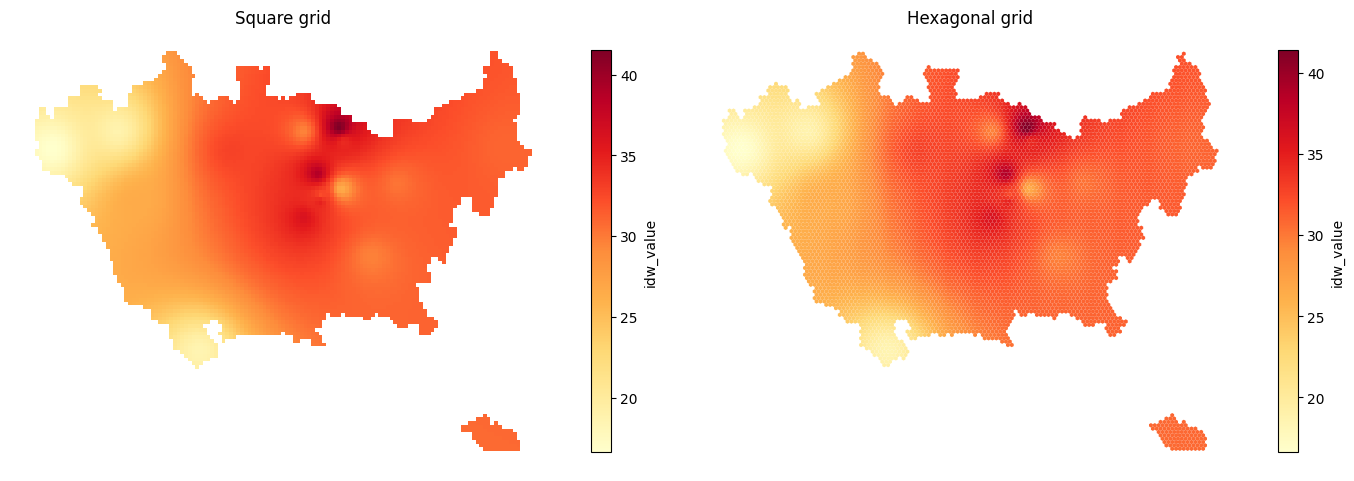

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
gx.plot_choropleth(sq_grid, "idw_value", cmap="YlOrRd", ax=axes[0], title="Square grid")
gx.plot_choropleth(hx_grid, "idw_value", cmap="YlOrRd", ax=axes[1], title="Hexagonal grid")
plt.tight_layout()

## Conclusions

* On real Milan data the **population-weighted exposure exceeds the area mean**
  (positive bias): a pollution-map average underestimates what people actually
  breathe.
* The **high-exposure quartile** carries markedly higher exposure than the
  low-exposure quartile, and a large share of the population lives there — an
  environmental-justice signal.
* A **MAUP sensitivity analysis** (resolution 250–1000 m; square vs hexagonal)
  shows the findings are stable, so they are not artefacts of the grid.